In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

<h3 style="background-color:#a4a4a4; color:#201c20; text-align:center; padding:8px; border-radius:8px;">
    <b> Dataset Selection</b>
</h3>

In [ ]:
df=pd.read_csv(r"RTA Dataset.csv")
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [3]:
df.shape

(12316, 32)

In [4]:
drop_cols = [
    'Time', 'Educational_level', 'Vehicle_driver_relation',
    'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
    'Types_of_Junction', 'Road_allignment', 'Road_surface_type',
    'Vehicle_type', 'Casualty_class', 'Cause_of_accident'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [5]:
df.columns

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Driving_experience', 'Type_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Road_surface_conditions', 'Light_conditions',
       'Weather_conditions', 'Type_of_collision',
       'Number_of_vehicles_involved', 'Number_of_casualties',
       'Vehicle_movement', 'Sex_of_casualty', 'Age_band_of_casualty',
       'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality',
       'Pedestrian_movement', 'Accident_severity'],
      dtype='object')

In [6]:
df.describe(include='object')

,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Vehicle_movement,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Accident_severity
count,12316,12316,12316,11487,11366,8388,7889,12316,12316,12316,12161,12008,12316,12316,12316,9118,9681,12316,12316
unique,7,5,3,7,17,6,3,4,4,9,10,13,3,6,4,7,5,9,3
top,Friday,18-30,Male,5-10yr,Automobile,Unknown,No defect,Dry,Daylight,Normal,Vehicle with vehicle collision,Going straight,Male,na,3,Driver,Normal,Not a Pedestrian,Slight Injury
freq,2041,4271,11437,3363,3205,2883,7777,9340,8798,10063,8774,8158,5253,4443,7076,5903,9608,11390,10415


In [7]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Day_of_week                  12316 non-null  object
 1   Age_band_of_driver           12316 non-null  object
 2   Sex_of_driver                12316 non-null  object
 3   Driving_experience           11487 non-null  object
 4   Type_of_vehicle              11366 non-null  object
 5   Service_year_of_vehicle      8388 non-null   object
 6   Defect_of_vehicle            7889 non-null   object
 7   Road_surface_conditions      12316 non-null  object
 8   Light_conditions             12316 non-null  object
 9   Weather_conditions           12316 non-null  object
 10  Type_of_collision            12161 non-null  object
 11  Number_of_vehicles_involved  12316 non-null  int64 
 12  Number_of_casualties         12316 non-null  int64 
 13  Vehicle_movement             12

<h3 style="background-color:#a4a4a4; color:#201c20; text-align:center; padding:8px; border-radius:8px;">
    <b>Data Cleaning</b>
</h3>

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
12311    False
12312    False
12313    False
12314    False
12315    False
Length: 12316, dtype: bool

In [10]:
df.isnull().sum()

Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Driving_experience              829
Type_of_vehicle                 950
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality              3198
Fitness_of_casuality           2635
Pedestrian_movement               0
Accident_severity                 0
dtype: int64

In [11]:
for col in df.columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [12]:
df.isnull().sum()

Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Driving_experience             0
Type_of_vehicle                0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           0
Pedestrian_movement            0
Accident_severity              0
dtype: int64

In [13]:
datadict=pd.DataFrame(df.dtypes)
datadict['MissingVal'] =df.isnull().sum()
datadict['NUnique']=df.nunique()
datadict['Count']=df.count()
datadict = datadict.rename(columns={0:'DataType'})
datadict

,DataType,MissingVal,NUnique,Count
Day_of_week,object,0,7,12316
Age_band_of_driver,object,0,5,12316
Sex_of_driver,object,0,3,12316
Driving_experience,object,0,7,12316
Type_of_vehicle,object,0,17,12316
Service_year_of_vehicle,object,0,6,12316
Defect_of_vehicle,object,0,3,12316
Road_surface_conditions,object,0,4,12316
Light_conditions,object,0,4,12316
Weather_conditions,object,0,9,12316


In [14]:
col_num=df.select_dtypes(include='number')
col_num

,Number_of_vehicles_involved,Number_of_casualties
0,2,2
1,2,2
2,2,2
3,2,2
4,2,2
...,...,...
12311,2,1
12312,2,1
12313,1,1
12314,2,1


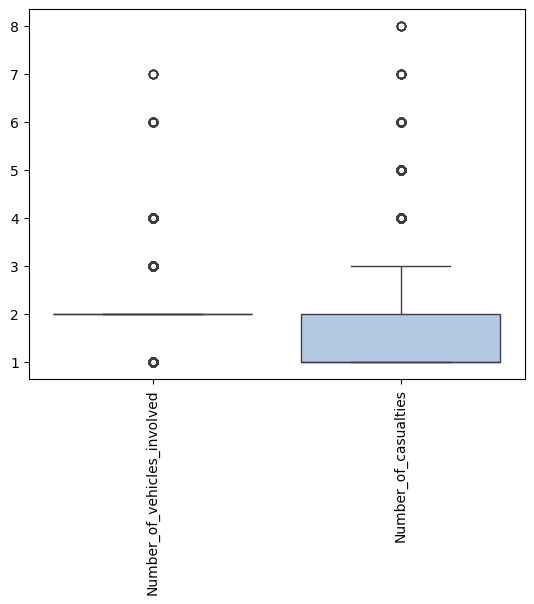

In [15]:
sns.boxplot(data=df, palette="tab20")
plt.xticks(rotation=90)
plt.xticks(rotation=90)
plt.show()

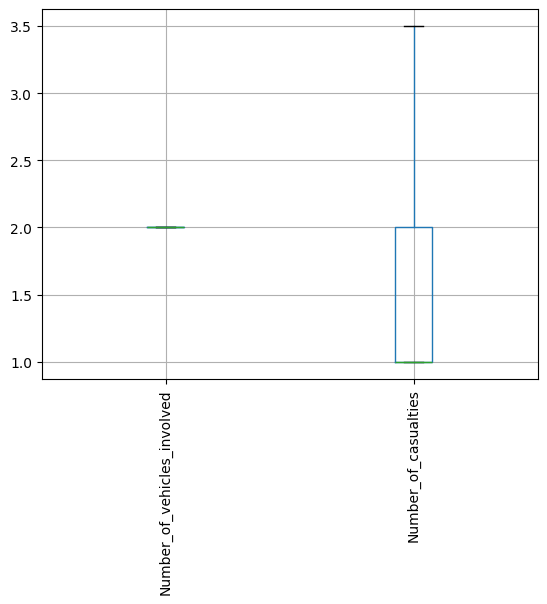

In [16]:
for x in col_num:
    Q1=df[x].quantile(.25)
    Q3=df[x].quantile(.75)
    IQR=Q3-Q1
    l_limit=Q1-1.5*IQR
    u_limit=Q3+1.5*IQR
    df[x]=df[x].clip(l_limit,u_limit)
df.boxplot()
plt.xticks(rotation=90)
plt.show()


<h3 style="background-color:#a4a4a4; color:#201c20; text-align:center; padding:8px; border-radius:8px;">
    <b>Basic EDA (Charts & Observations)</b>
</h3>

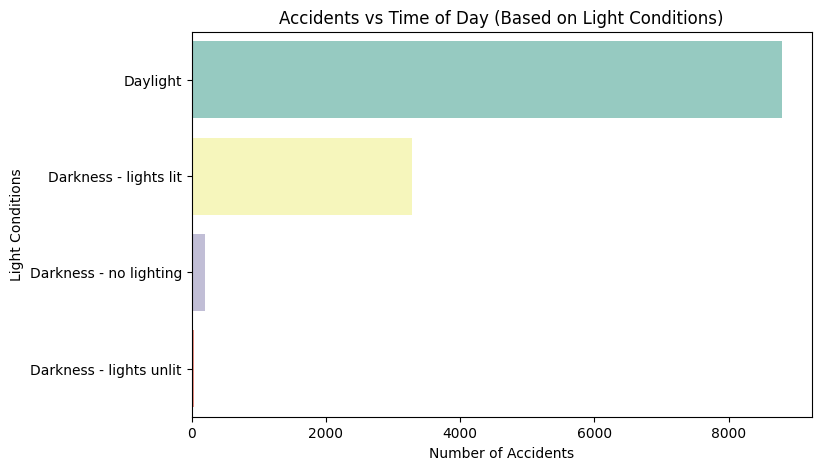

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(
    y='Light_conditions',
    data=df,
    palette='Set3',
    order=df['Light_conditions'].value_counts().index
)

plt.title('Accidents vs Time of Day (Based on Light Conditions)')
plt.xlabel('Number of Accidents')
plt.ylabel('Light Conditions')
plt.show()


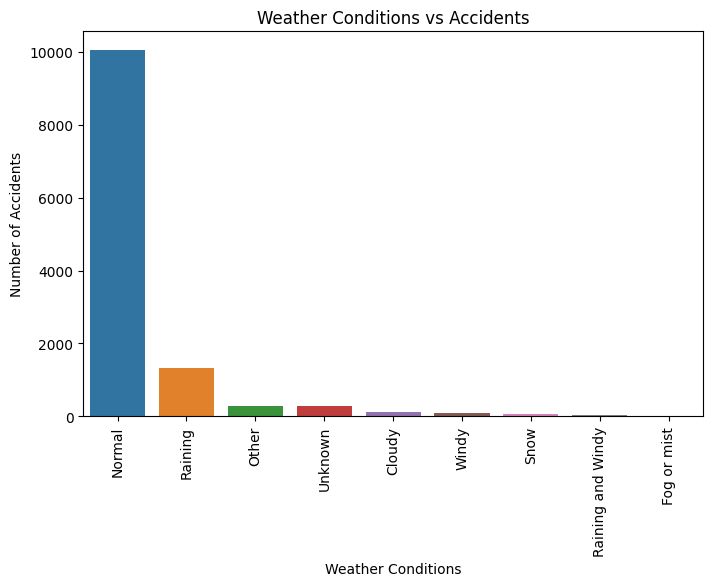

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(
    x='Weather_conditions',
    data=df,
    order=df['Weather_conditions'].value_counts().index,
    palette="tab10"
)

plt.title('Weather Conditions vs Accidents')
plt.xlabel('Weather Conditions')
plt.xticks(rotation=90)
plt.ylabel('Number of Accidents')
plt.show()


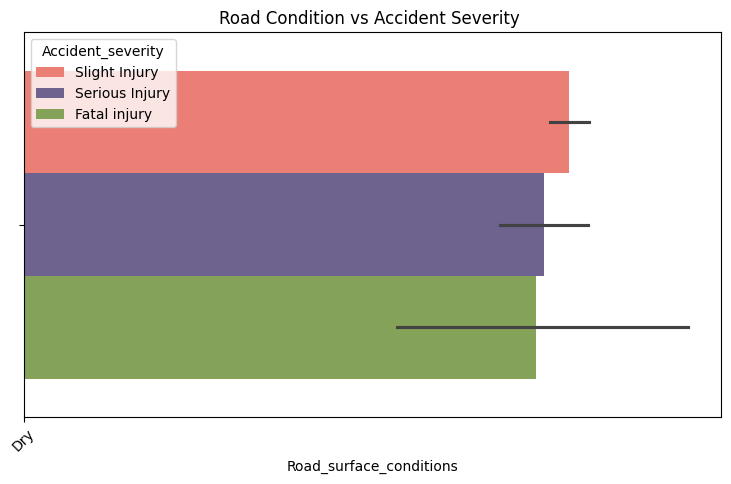

In [19]:
plt.figure(figsize=(9,5))
sns.barplot(
    x='Road_surface_conditions',
    hue='Accident_severity',
    data=df,
    palette=["#FF6F61", "#6B5B95", "#88B04B"]
)

plt.title('Road Condition vs Accident Severity ')
plt.xticks(rotation=45)
plt.show()

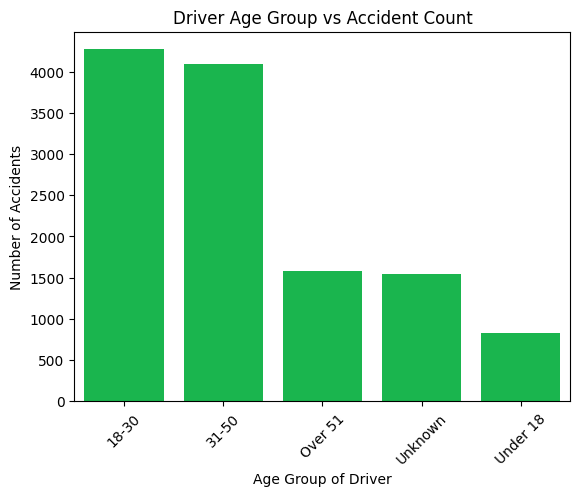

In [20]:
sns.countplot(
    x='Age_band_of_driver',
    data=df,
    order=df['Age_band_of_driver'].value_counts().index,
    color="#00CF45"
)

plt.title('Driver Age Group vs Accident Count')
plt.xlabel('Age Group of Driver')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

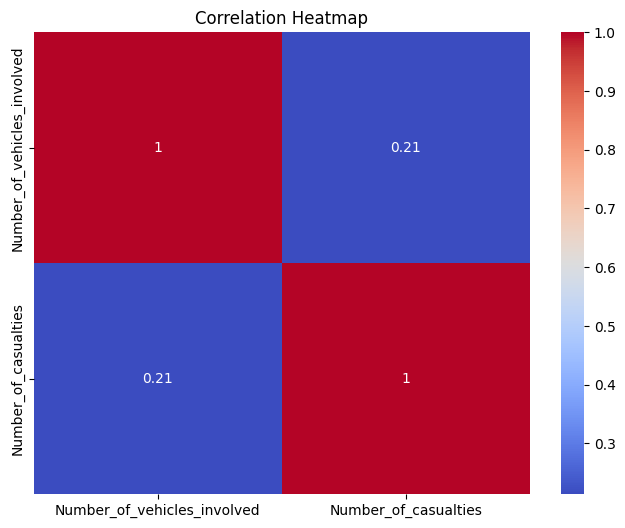

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(col_num.corr(), annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [22]:
datadict

,DataType,MissingVal,NUnique,Count
Day_of_week,object,0,7,12316
Age_band_of_driver,object,0,5,12316
Sex_of_driver,object,0,3,12316
Driving_experience,object,0,7,12316
Type_of_vehicle,object,0,17,12316
Service_year_of_vehicle,object,0,6,12316
Defect_of_vehicle,object,0,3,12316
Road_surface_conditions,object,0,4,12316
Light_conditions,object,0,4,12316
Weather_conditions,object,0,9,12316


In [23]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in[
    'Day_of_week',
    'Age_band_of_driver',
    'Sex_of_driver',
    'Driving_experience',
    'Type_of_vehicle',
    'Service_year_of_vehicle',
    'Defect_of_vehicle',
    'Road_surface_conditions',
    'Light_conditions',
    'Weather_conditions',
    'Type_of_collision',
    'Vehicle_movement',
    'Sex_of_casualty',
    'Age_band_of_casualty',
    'Casualty_severity',
    'Work_of_casuality',
    'Fitness_of_casuality',
    'Pedestrian_movement',
    'Accident_severity'
]:
    df[i]=le.fit_transform(df[i])

In [24]:
df

,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Road_surface_conditions,Light_conditions,Weather_conditions,...,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Accident_severity
0,1,0,1,0,0,3,2,0,3,2,...,2,2.0,2,2,5,3,0,2,5,2
1,1,1,1,3,11,2,2,0,3,2,...,2,2.0,2,2,5,3,0,2,5,2
2,1,0,1,0,5,5,2,0,3,2,...,2,2.0,2,1,1,2,0,2,5,1
3,3,0,1,2,11,5,2,0,0,2,...,2,2.0,2,0,0,2,0,2,5,2
4,3,0,1,1,0,2,2,0,0,2,...,2,2.0,2,2,5,3,0,2,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,6,1,1,1,4,5,2,0,3,2,...,2,1.0,2,2,5,3,0,2,5,2
12312,3,4,1,2,0,5,2,0,3,2,...,2,1.0,4,2,5,3,0,2,5,2
12313,3,2,1,2,1,1,2,0,3,2,...,2,1.0,4,1,1,2,0,2,5,1
12314,3,0,0,3,5,1,2,0,0,2,...,2,1.0,4,2,5,3,0,2,5,2


In [25]:
df.columns

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Driving_experience', 'Type_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Road_surface_conditions', 'Light_conditions',
       'Weather_conditions', 'Type_of_collision',
       'Number_of_vehicles_involved', 'Number_of_casualties',
       'Vehicle_movement', 'Sex_of_casualty', 'Age_band_of_casualty',
       'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality',
       'Pedestrian_movement', 'Accident_severity'],
      dtype='object')

In [26]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
cols=['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Driving_experience', 'Type_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Road_surface_conditions', 'Light_conditions',
       'Weather_conditions', 'Type_of_collision',
       'Number_of_vehicles_involved', 'Number_of_casualties',
       'Vehicle_movement', 'Sex_of_casualty', 'Age_band_of_casualty',
       'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality',
       'Pedestrian_movement']
for i in cols:
    df[i]=sc.fit_transform(df[[i]])

In [27]:
sd=sc.fit_transform(df[cols])
df[['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Driving_experience', 'Type_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Road_surface_conditions', 'Light_conditions',
       'Weather_conditions', 'Type_of_collision',
       'Number_of_vehicles_involved', 'Number_of_casualties',
       'Vehicle_movement', 'Sex_of_casualty', 'Age_band_of_casualty',
       'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality',
       'Pedestrian_movement']]=pd.DataFrame(sd,columns=cols)

<h3 style="background-color:#a4a4a4; color:#201c20; text-align:center; padding:8px; border-radius:8px;">
    <b>Dataset Split</b>
</h3>

In [28]:
x=df.drop('Accident_severity',axis=1)
x

,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement
0,-0.961588,-0.966718,0.161001,-1.572477,-1.121296,-0.295792,0.090277,-0.5634,0.621167,-0.362059,-1.248921,0.0,0.662692,-0.420264,1.147173,1.121635,1.201397,-0.552066,-0.00067,0.183458
1,-0.961588,-0.219035,0.161001,0.854520,1.297017,-0.851207,0.090277,-0.5634,0.621167,-0.362059,0.584811,0.0,0.662692,-0.420264,1.147173,1.121635,1.201397,-0.552066,-0.00067,0.183458
2,-0.961588,-0.966718,0.161001,-1.572477,-0.022063,0.815040,0.090277,-0.5634,0.621167,-0.362059,-1.615667,0.0,0.662692,-0.420264,-0.199304,-0.764243,-0.500122,-0.552066,-0.00067,0.183458
3,0.009461,-0.966718,0.161001,0.045521,1.297017,0.815040,0.090277,-0.5634,-1.644466,-0.362059,0.584811,0.0,0.662692,-0.420264,-1.545781,-1.235712,-0.500122,-0.552066,-0.00067,0.183458
4,0.009461,-0.966718,0.161001,-0.763478,-1.121296,-0.851207,0.090277,-0.5634,-1.644466,-0.362059,0.584811,0.0,0.662692,-0.420264,1.147173,1.121635,1.201397,-0.552066,-0.00067,0.183458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,1.466035,-0.219035,0.161001,-0.763478,-0.241910,0.815040,0.090277,-0.5634,0.621167,-0.362059,0.584811,0.0,-0.610984,-0.420264,1.147173,1.121635,1.201397,-0.552066,-0.00067,0.183458
12312,0.009461,2.024013,0.161001,0.045521,-1.121296,0.815040,0.090277,-0.5634,0.621167,-0.362059,0.584811,0.0,-0.610984,0.551932,1.147173,1.121635,1.201397,-0.552066,-0.00067,0.183458
12313,0.009461,0.528648,0.161001,0.045521,-0.901450,-1.406623,0.090277,-0.5634,0.621167,-0.362059,0.584811,0.0,-0.610984,0.551932,-0.199304,-0.764243,-0.500122,-0.552066,-0.00067,0.183458
12314,0.009461,-0.966718,-3.630380,0.854520,-0.022063,-1.406623,0.090277,-0.5634,-1.644466,-0.362059,0.584811,0.0,-0.610984,0.551932,1.147173,1.121635,1.201397,-0.552066,-0.00067,0.183458


In [29]:
y=df['Accident_severity']
y

0        2
1        2
2        1
3        2
4        2
        ..
12311    2
12312    2
12313    1
12314    2
12315    2
Name: Accident_severity, Length: 12316, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

<h3 style="background-color:#a4a4a4; color:#201c20; text-align:center; padding:8px; border-radius:8px;">
    <b>Model Training</b>
</h3>

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
model_logistic= LogisticRegression()

In [32]:
model_logistic=model_logistic.fit(x_train,y_train)
y_logistic=model_logistic.predict(x_test)

In [33]:
acc_logistic=accuracy_score(y_test,y_logistic)
acc_logistic

0.8376623376623377

In [34]:
from sklearn.ensemble import RandomForestClassifier
model_rf= RandomForestClassifier(n_estimators=100, random_state=42)
model_rf=model_rf.fit(x_train,y_train)

In [35]:
y_pred_rf=model_rf.predict(x_test)


In [36]:
acc_rf = accuracy_score(y_test,y_pred_rf)
acc_rf

0.8348214285714286

<h3 style="background-color:#a4a4a4; color:#201c20; text-align:center; padding:8px; border-radius:8px;">
    <b>Model Evaluation</b>
</h3>

In [37]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred_rf, average='weighted')
precision


0.7457749144350685

In [38]:
from sklearn.metrics import recall_score
recall=recall_score(y_test,y_pred_rf, average='weighted')
recall

0.8348214285714286

In [39]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,y_pred_rf, average='weighted')
f1

0.7659620567700159

<h3 style="background-color:#a4a4a4; color:#201c20; text-align:center; padding:8px; border-radius:8px;">
    <b>Model Tuning</b>
</h3>

In [40]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [41]:
grid = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [42]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}


In [48]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [49]:
random_search = RandomizedSearchCV(model_rf, param_distributions=param_dist, n_iter=10,
cv=5)
random_search.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [50]:
print(random_search.best_params_)

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}


In [ ]:
f_model=RandomForestClassifier(n_estimators=200,min_samples_split=10,min_samples_leaf=2,max_depth=None)
f_model.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
y_pred_f=f_model.predict(x_test)

In [53]:
f_acc=accuracy_score(y_test,y_pred_f)
f_acc

0.8380681818181818

In [54]:
new_data=[[-0.961588,-0.966718,0.161001,-1.572477,-1.121296,-0.295792,0.090277,-0.5634,0.621167,-0.362059,-1.248921,0.0,0.662692,-0.420264,1.147173,1.121635,1.201397,-0.552066,-0.00067,0.183458]]

In [55]:
prediction=f_model.predict(new_data)
prediction

array([2])

<h3 style="background-color:#a4a4a4; color:#201c20; text-align:center; padding:8px; border-radius:8px;">
    <b>Feature Importance</b>
</h3>

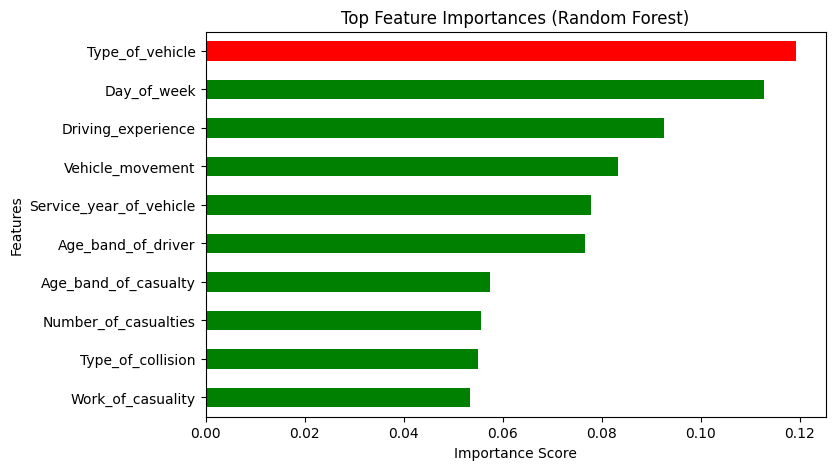

In [73]:
feature_importance = pd.Series(
    f_model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)
plt.figure(figsize=(8,5))
colors = ['red'] + ['green'] * 9

feature_importance.head(10).plot(kind='barh',
                                 color=colors)
plt.title('Top Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.show()

<h3 style="background-color:#a4a4a4; color:#201c20; text-align:center; padding:8px; border-radius:8px;">
    <b>Error Analysis</b>
</h3>

In [77]:

results = x_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred_f 

errors = results[results['Actual'] != results['Predicted']]

errors.head()


,Day_of_week,Age_band_of_driver,Sex_of_driver,Driving_experience,Type_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Road_surface_conditions,Light_conditions,Weather_conditions,...,Number_of_casualties,Vehicle_movement,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Actual,Predicted
1022,1.466035,-0.966718,0.161001,0.045521,-1.121296,0.815040,0.090277,-0.563400,0.621167,-0.362059,...,-0.610984,-0.906362,-0.199304,-1.235712,-0.500122,-0.552066,-0.00067,0.183458,1,2
5641,-1.447112,1.276330,0.161001,0.854520,0.637477,0.815040,0.090277,1.787684,0.621167,-0.362059,...,-0.610984,0.551932,-0.199304,0.650165,-0.500122,-0.552066,-0.00067,0.183458,1,2
9068,0.009461,-0.966718,0.161001,0.854520,-1.121296,0.815040,0.090277,1.787684,0.621167,1.383194,...,2.573206,-0.420264,-0.199304,0.650165,-0.500122,1.904899,-0.00067,0.183458,0,2
9591,1.466035,-0.219035,0.161001,0.045521,0.857323,0.815040,0.090277,-0.563400,0.621167,-0.362059,...,-0.610984,-0.420264,-0.199304,-0.764243,-0.500122,1.904899,-0.00067,0.183458,1,2
3412,0.009461,2.024013,0.161001,-0.763478,1.077170,-0.295792,0.090277,-0.563400,-1.644466,-0.362059,...,1.936368,-0.420264,-0.199304,-0.764243,-0.500122,-0.552066,-0.00067,0.183458,1,2


In [78]:
errors['Actual'].value_counts()

Actual
1    362
0     37
Name: count, dtype: int64

### Reason 1: Overlapping feature patterns

Many accidents share similar conditions (weather, road surface, and lighting), making it difficult for the model to clearly distinguish between different severity levels.

### Reason 2: Missing human behavior factors

The dataset does not include important factors such as driver speed, alcohol consumption, or distraction, which significantly affect accident severity.